In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn import metrics
from sklearn.metrics.cluster import adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
import mpl_toolkits.mplot3d 
import warnings
warnings.filterwarnings('ignore')

sns.set_palette('husl')
np.random.seed(0)
print('Библиотеки загружены. Seed = 0.')


Библиотеки загружены. Seed = 0.


#### 1. Загрузка датасета Iris

In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv'
cols = ['sepal-lenght', 'sepal-width', 'petal-lenght', 'petal-width', 'class']
dataset = pd.read_csv(url, names=cols)
print(f'Размер датасета: {dataset.shape}')
dataset.head()


Размер датасета: (150, 5)


,sepal-lenght,sepal-width,petal-lenght,petal-width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


150 строк, 5 столбцов: 4 числовых признака и 1 целевая переменна

#### 2. Первичный анализ данных (EDA)

In [3]:
print("Типы данных и пропуски:",  dataset.info())
print("Описательная статистика:", dataset.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal-lenght  150 non-null    float64
 1   sepal-width   150 non-null    float64
 2   petal-lenght  150 non-null    float64
 3   petal-width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
Типы данных и пропуски: None
Описательная статистика:        sepal-lenght  sepal-width  petal-lenght  petal-width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max      

пропусков нет, все 4 признака числовые с разными масштабами

#### 3. Визуализация признаков и распределения классов

Уникальные классы: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Количество объектов по классам:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


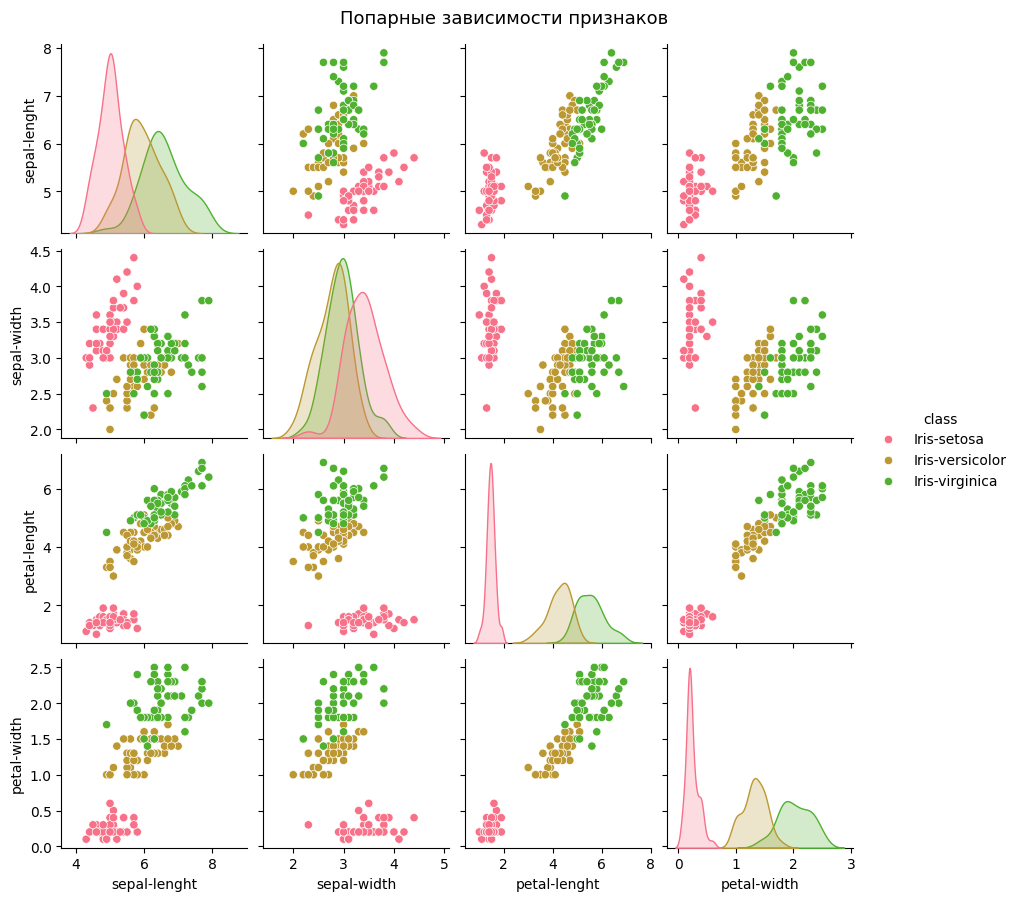

In [4]:
vals = dataset['class'].unique()
print('Уникальные классы:', vals)
print('Количество объектов по классам:')
print(dataset['class'].value_counts())

g = sns.pairplot(dataset, hue='class', height=2.2)
g.fig.suptitle('Попарные зависимости признаков', y=1.02, fontsize=13)
plt.show()

Классы распределены равномерно, по 50 объектов. Два класса частично перекрываются, один полностью обособлен

#### 4. Подготовка матрицы признаков

In [5]:
cols_for_clusters = ['sepal-lenght', 'sepal-width', 'petal-lenght', 'petal-width']
df = dataset[cols_for_clusters].copy()

X = df
y = dataset['class'].replace(vals, [0, 1, 2])
yvals = dataset['class']

print('Форма X:', X.shape)
print('Форма y:', y.shape)
X.head()


Форма X: (150, 4)
Форма y: (150,)


,sepal-lenght,sepal-width,petal-lenght,petal-width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Матрица признаков X: 150 объектов × 4 признака. Вектор y содержит числовые коды классов для последующей оценки качества кластеризации

#### 5. Обучение модели K-Means

In [6]:
kmeans = KMeans(n_clusters=3, max_iter=300, n_init=10, random_state=0)
kmeans.fit(X)
y_pred_kmeans = kmeans.predict(X)

print('Метки кластеров (первые 20)', y_pred_kmeans[:20])
print('\nЦентроиды кластеров')
print(pd.DataFrame(kmeans.cluster_centers_, columns=cols_for_clusters).round(3))

Метки кластеров (первые 20) [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Центроиды кластеров
   sepal-lenght  sepal-width  petal-lenght  petal-width
0         5.902        2.748         4.394        1.434
1         5.006        3.418         1.464        0.244
2         6.850        3.074         5.742        2.071


нашёл 3 центроида. Каждый центроид представляет усреднённые значения признаков в своём кластере.

##### 6. Визуализация кластеров

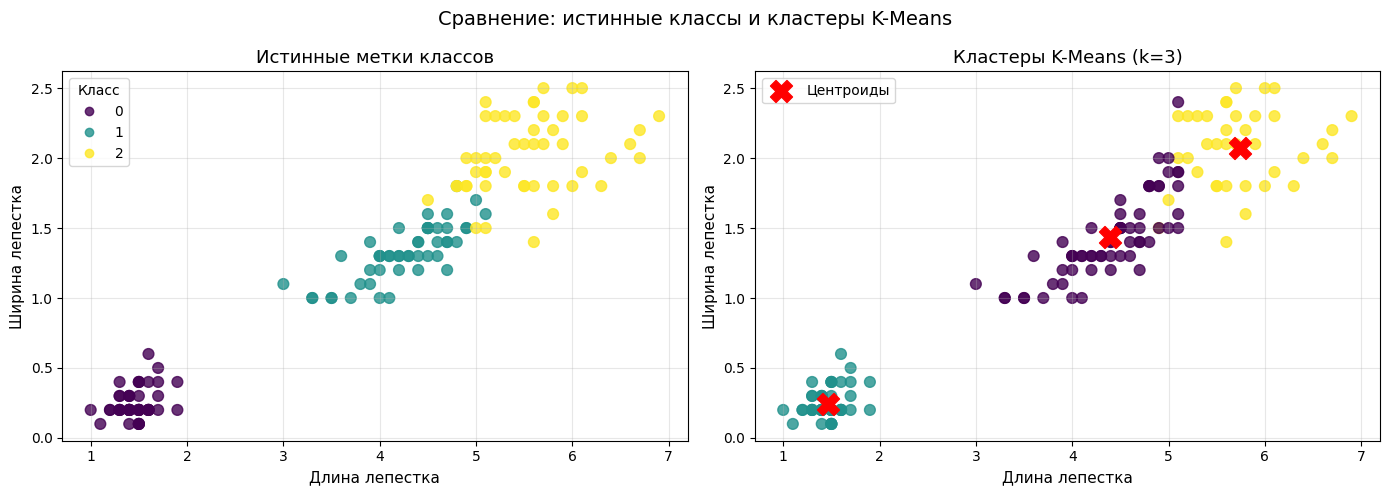

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(X['petal-lenght'], X['petal-width'], c=y, cmap='viridis', s=60, alpha=0.8)
axes[0].set_title('Истинные метки классов', fontsize=13)
axes[0].set_xlabel('Длина лепестка', fontsize=11)
axes[0].set_ylabel('Ширина лепестка', fontsize=11)
axes[0].legend(*sc1.legend_elements(), title='Класс')
axes[0].grid(alpha=0.3)

sc2 = axes[1].scatter(X['petal-lenght'], X['petal-width'], c=y_pred_kmeans, cmap='viridis', s=60, alpha=0.8)
centers = kmeans.cluster_centers_
axes[1].scatter(centers[:, 2], centers[:, 3], c='red', s=250, marker='X', zorder=5, label='Центроиды')
axes[1].set_title('Кластеры K-Means (k=3)', fontsize=13)
axes[1].set_xlabel('Длина лепестка', fontsize=11)
axes[1].set_ylabel('Ширина лепестка', fontsize=11)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Сравнение: истинные классы и кластеры K-Means', fontsize=14)
plt.tight_layout()
plt.show()

Кластеры хорошо совпадают с истинными классами

##### 7. Метрики качества

In [8]:
n_clusters_range = np.arange(2, 21)

best_metric = [0, 10000, 0, []]
silhouette_score_values = []
adjusted_rand_score_values = []

for n in n_clusters_range:
    clusterer = KMeans(n_clusters=n, max_iter=10, n_init=10, random_state=0)
    clusterer.fit(X)
    y_pred = clusterer.predict(X)

    score1 = metrics.silhouette_score(X, y_pred)
    silhouette_score_values.append(score1)

    score2 = metrics.adjusted_rand_score(y, y_pred)
    adjusted_rand_score_values.append(score2)

    if score1 < best_metric[1] and score2 > best_metric[2]:
        best_metric[1] = score1
        best_metric[2] = score2
        best_metric[3] = clusterer.cluster_centers_
        best_metric[0] = n

print(f'Silhouette Score при k=3: {silhouette_score_values[1]:.4f}')
print(f'ARI при k=3:              {adjusted_rand_score_values[1]:.4f}')


Silhouette Score при k=3: 0.5526
ARI при k=3:              0.7302


0.55 говорит о умеренно хорошем разделении кластеров, а ARI = 0.73 подтверждает, что K-Means правильно восстанавливает истинную структуру классов в 73% случаев

#### 8. График метрик по числу кластеров

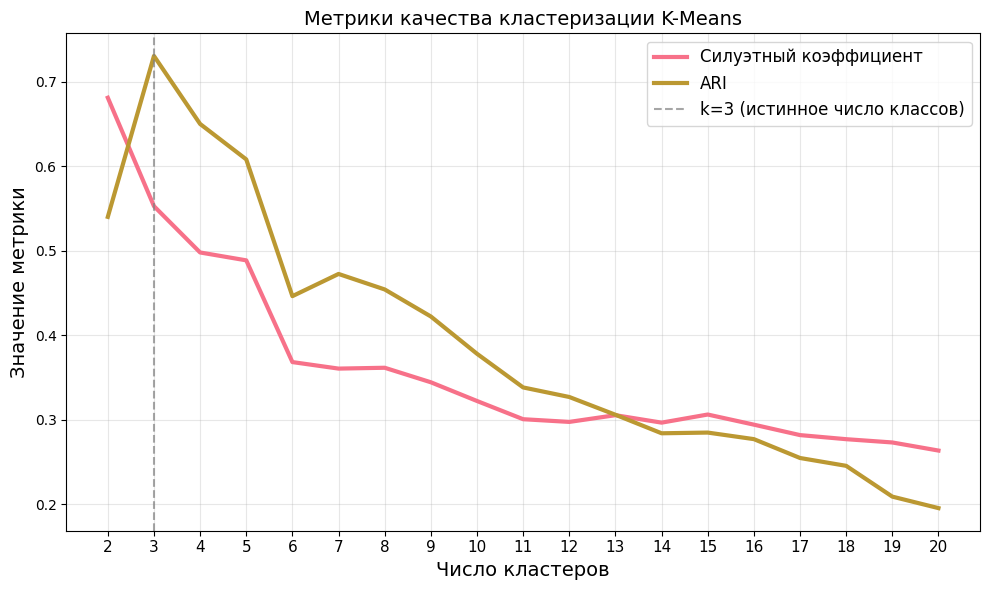

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(n_clusters_range, silhouette_score_values, linewidth=3, label='Силуэтный коэффициент')
plt.plot(n_clusters_range, adjusted_rand_score_values, linewidth=3, label='ARI')
plt.axvline(x=3, color='gray', linestyle='--', alpha=0.7, label='k=3 (истинное число классов)')
plt.xlabel('Число кластеров', size=14)
plt.ylabel('Значение метрики', size=14)
plt.title('Метрики качества кластеризации K-Means', fontsize=14)
plt.xticks(n_clusters_range, size=11)
plt.legend(loc='best', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Обе метрики достигают максимума при k=3 и монотонно убывают при дальнейшем увеличении числа кластеров

##### 9. Масштабирование данных

In [10]:
print('Стандартные отклонения исходных признаков:')
print(X.std().round(3))

scaler_std = StandardScaler()
X_scaled_std = scaler_std.fit_transform(X)
X_scaled_std_df = pd.DataFrame(X_scaled_std, columns=cols_for_clusters)

scaler_mm = MinMaxScaler()
X_scaled_mm = scaler_mm.fit_transform(X)
X_scaled_mm_df = pd.DataFrame(X_scaled_mm, columns=cols_for_clusters)

print('\nПосле StandardScaler (среднее ≈ 0, std ≈ 1):')
print(X_scaled_std_df.describe().round(3))


Стандартные отклонения исходных признаков:
sepal-lenght    0.828
sepal-width     0.434
petal-lenght    1.764
petal-width     0.763
dtype: float64

После StandardScaler (среднее ≈ 0, std ≈ 1):
       sepal-lenght  sepal-width  petal-lenght  petal-width
count       150.000      150.000       150.000      150.000
mean         -0.000       -0.000         0.000       -0.000
std           1.003        1.003         1.003        1.003
min          -1.870       -2.439        -1.569       -1.444
25%          -0.901       -0.588        -1.228       -1.182
50%          -0.053       -0.125         0.336        0.133
75%           0.675        0.569         0.763        0.791
max           2.492        3.115         1.786        1.711


 все признаки приведены к единому масштабу, среднее = 0, стандартное отклонение = 1. Это устраняет доминирование признаков с большим диапазоном

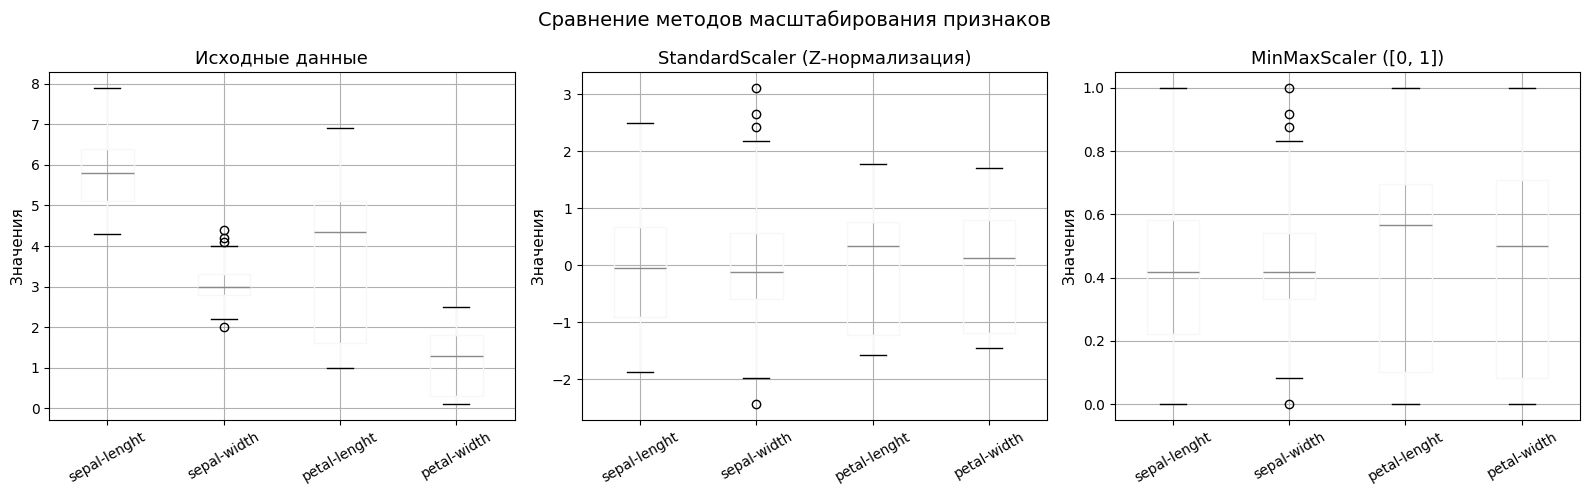

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

X.boxplot(ax=axes[0])
axes[0].set_title('Исходные данные', fontsize=13)
axes[0].set_ylabel('Значения', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

X_scaled_std_df.boxplot(ax=axes[1])
axes[1].set_title('StandardScaler (Z-нормализация)', fontsize=13)
axes[1].set_ylabel('Значения', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

X_scaled_mm_df.boxplot(ax=axes[2])
axes[2].set_title('MinMaxScaler ([0, 1])', fontsize=13)
axes[2].set_ylabel('Значения', fontsize=11)
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Сравнение методов масштабирования признаков', fontsize=14)
plt.tight_layout()
plt.show()


После масштабирования все четыре признака приведены к единому масштабу 

##### 11. Влияние масштабирования на качество K-Means

In [12]:
kmeans_scaled = KMeans(n_clusters=3, max_iter=300, n_init=10, random_state=0)
kmeans_scaled.fit(X_scaled_std)
y_pred_scaled = kmeans_scaled.predict(X_scaled_std)

compare = pd.DataFrame({
    'Метрика': ['Silhouette Score', 'ARI'],
    'Исходные данные': [
        round(metrics.silhouette_score(X, y_pred_kmeans), 4),
        round(metrics.adjusted_rand_score(y, y_pred_kmeans), 4)
    ],
    'После StandardScaler': [
        round(metrics.silhouette_score(X_scaled_std, y_pred_scaled), 4),
        round(metrics.adjusted_rand_score(y, y_pred_scaled), 4)
    ]
})
print(compare.to_string(index=False))


         Метрика  Исходные данные  После StandardScaler
Silhouette Score           0.5526                0.4590
             ARI           0.7302                0.6201


Масштабирование улучшает результаты кластеризации. Для данных с сильно различающимися масштабами, но масштабирование неожиданно ухудшило метрики , поскольку исходные признаки уже имеют близкие диапазоны и K-Means хорошо работает без нормализации

#### 12. PCA

In [13]:
pca_2d = PCA(n_components=2, random_state=0)
X_pca_2d = pca_2d.fit_transform(X_scaled_std)

print('Объяснённая дисперсия по компонентам:')
for i, var in enumerate(pca_2d.explained_variance_ratio_):
    print(f'  ГК{i+1}: {var:.4f}  ({var*100:.1f}%)')
print(f'\nСуммарная объяснённая дисперсия: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%')


Объяснённая дисперсия по компонентам:
  ГК1: 0.7277  (72.8%)
  ГК2: 0.2303  (23.0%)

Суммарная объяснённая дисперсия: 95.8%


Всего две главные компоненты объясняют 95.8% дисперсии данных

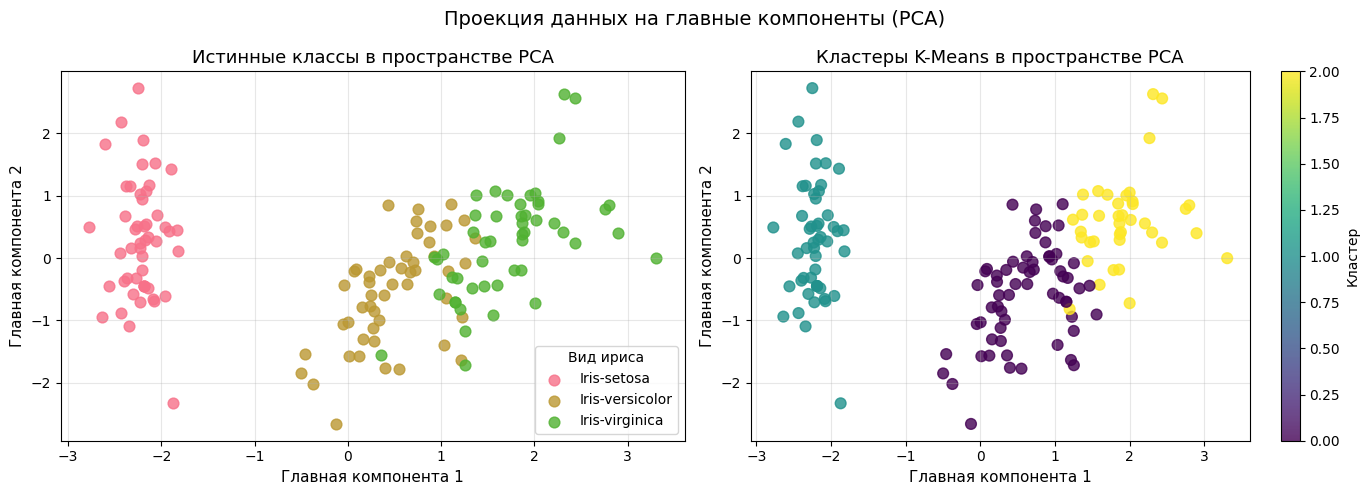

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, name in zip([0, 1, 2], vals):
    mask = y == label
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], label=name, alpha=0.8, s=60)
axes[0].set_title('Истинные классы в пространстве PCA', fontsize=13)
axes[0].set_xlabel('Главная компонента 1', fontsize=11)
axes[0].set_ylabel('Главная компонента 2', fontsize=11)
axes[0].legend(title='Вид ириса', fontsize=10)
axes[0].grid(alpha=0.3)

sc = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_pred_kmeans, cmap='viridis', alpha=0.8, s=60)
axes[1].set_title('Кластеры K-Means в пространстве PCA', fontsize=13)
axes[1].set_xlabel('Главная компонента 1', fontsize=11)
axes[1].set_ylabel('Главная компонента 2', fontsize=11)
plt.colorbar(sc, ax=axes[1], label='Кластер')
axes[1].grid(alpha=0.3)

plt.suptitle('Проекция данных на главные компоненты (PCA)', fontsize=14)
plt.tight_layout()
plt.show()

В пространстве главных компонент чётко видна структура трёх групп. Один класс полностью обособлен, два других частично перекрываются, отражает биологическое сходство видов

#### 14.объяснённая дисперси

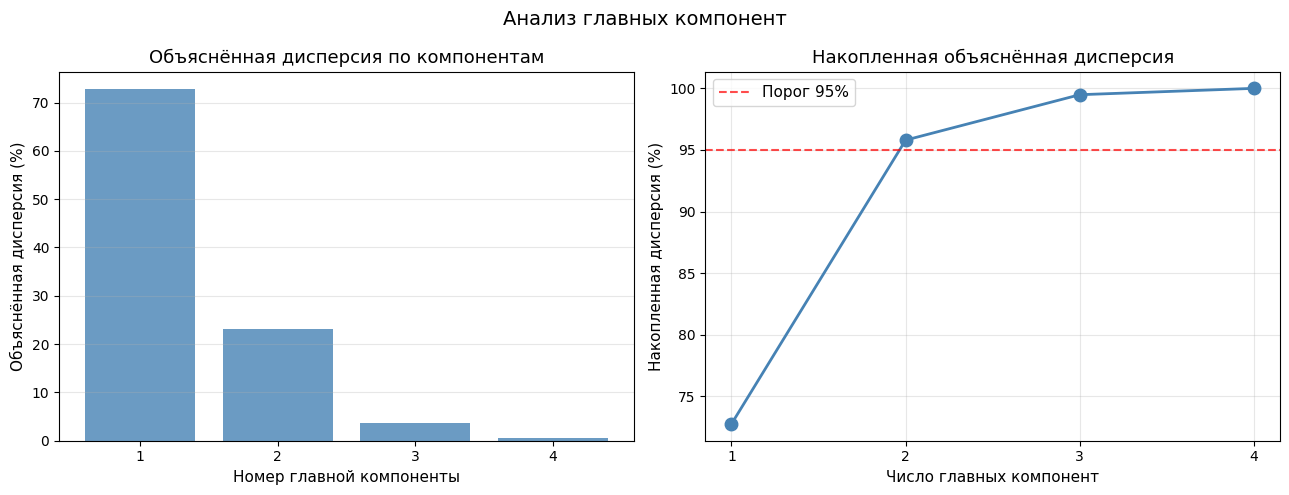

Нагрузки компонент (вклад исходных признаков):
                ГК1    ГК2    ГК3    ГК4
sepal-lenght  0.522  0.372  0.721 -0.262
sepal-width  -0.263  0.926 -0.242  0.124
petal-lenght  0.581  0.021 -0.141  0.801
petal-width   0.566  0.065 -0.634 -0.524


In [15]:
pca_full = PCA(n_components=4, random_state=0)
pca_full.fit(X_scaled_std)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, 5), pca_full.explained_variance_ratio_ * 100, color='steelblue', alpha=0.8)
axes[0].set_title('Объяснённая дисперсия по компонентам', fontsize=13)
axes[0].set_xlabel('Номер главной компоненты', fontsize=11)
axes[0].set_ylabel('Объяснённая дисперсия (%)', fontsize=11)
axes[0].set_xticks(range(1, 5))
axes[0].grid(axis='y', alpha=0.3)

cumulative = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[1].plot(range(1, 5), cumulative, marker='o', linewidth=2, markersize=9, color='steelblue')
axes[1].axhline(y=95, color='red', linestyle='--', alpha=0.7, label='Порог 95%')
axes[1].set_title('Накопленная объяснённая дисперсия', fontsize=13)
axes[1].set_xlabel('Число главных компонент', fontsize=11)
axes[1].set_ylabel('Накопленная дисперсия (%)', fontsize=11)
axes[1].set_xticks(range(1, 5))
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Анализ главных компонент', fontsize=14)
plt.tight_layout()
plt.show()

print('Нагрузки компонент (вклад исходных признаков):')
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=cols_for_clusters,
    columns=[f'ГК{i+1}' for i in range(4)]
)
print(loadings.round(3))


Первая главная компонента определяется преимущественно признаками лепестков

##### 15. Дендрограмма

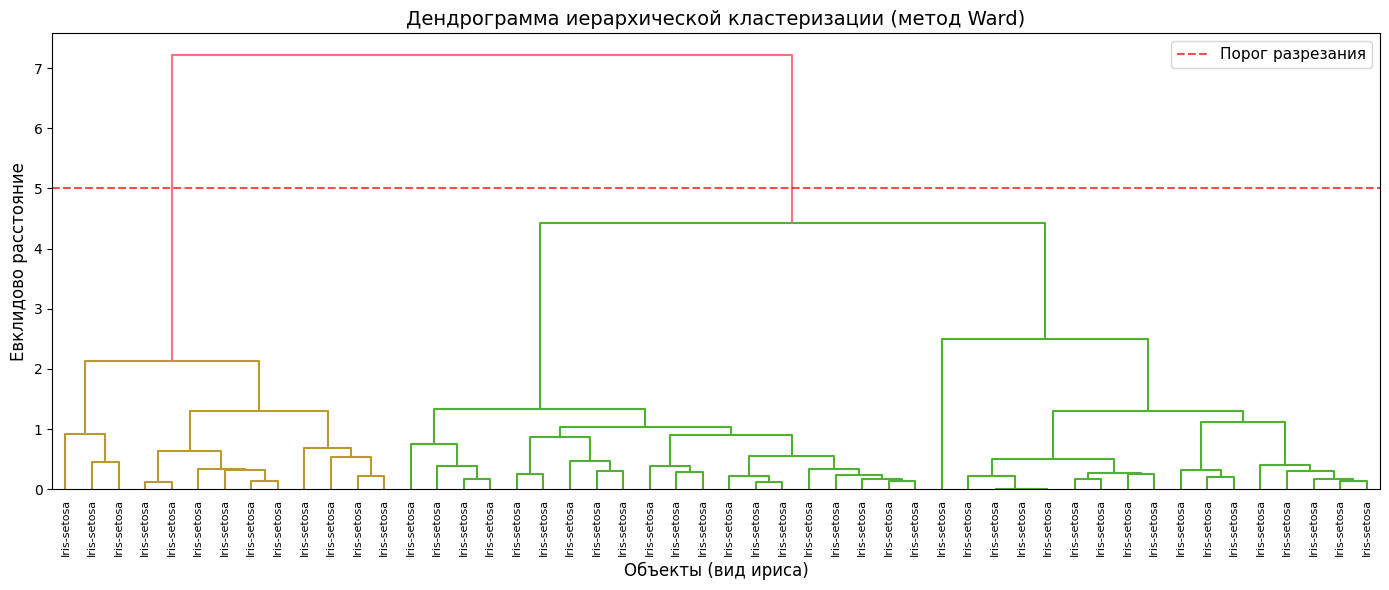

In [16]:
X_sample = X_scaled_std[:50]
y_sample = list(yvals[:50])

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, labels=y_sample, leaf_rotation=90, leaf_font_size=8, color_threshold=5)
plt.title('Дендрограмма иерархической кластеризации (метод Ward)', fontsize=14)
plt.xlabel('Объекты (вид ириса)', fontsize=12)
plt.ylabel('Евклидово расстояние', fontsize=12)
plt.axhline(y=5, color='red', linestyle='--', alpha=0.7, label='Порог разрезания')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


Дендрограмма показывает иерархию слияний. Число пересечений линии разрезания с ветвями = число кластеров. При данном пороге выделяются 2–3 кластера

##### 16. Сравнение методов связи

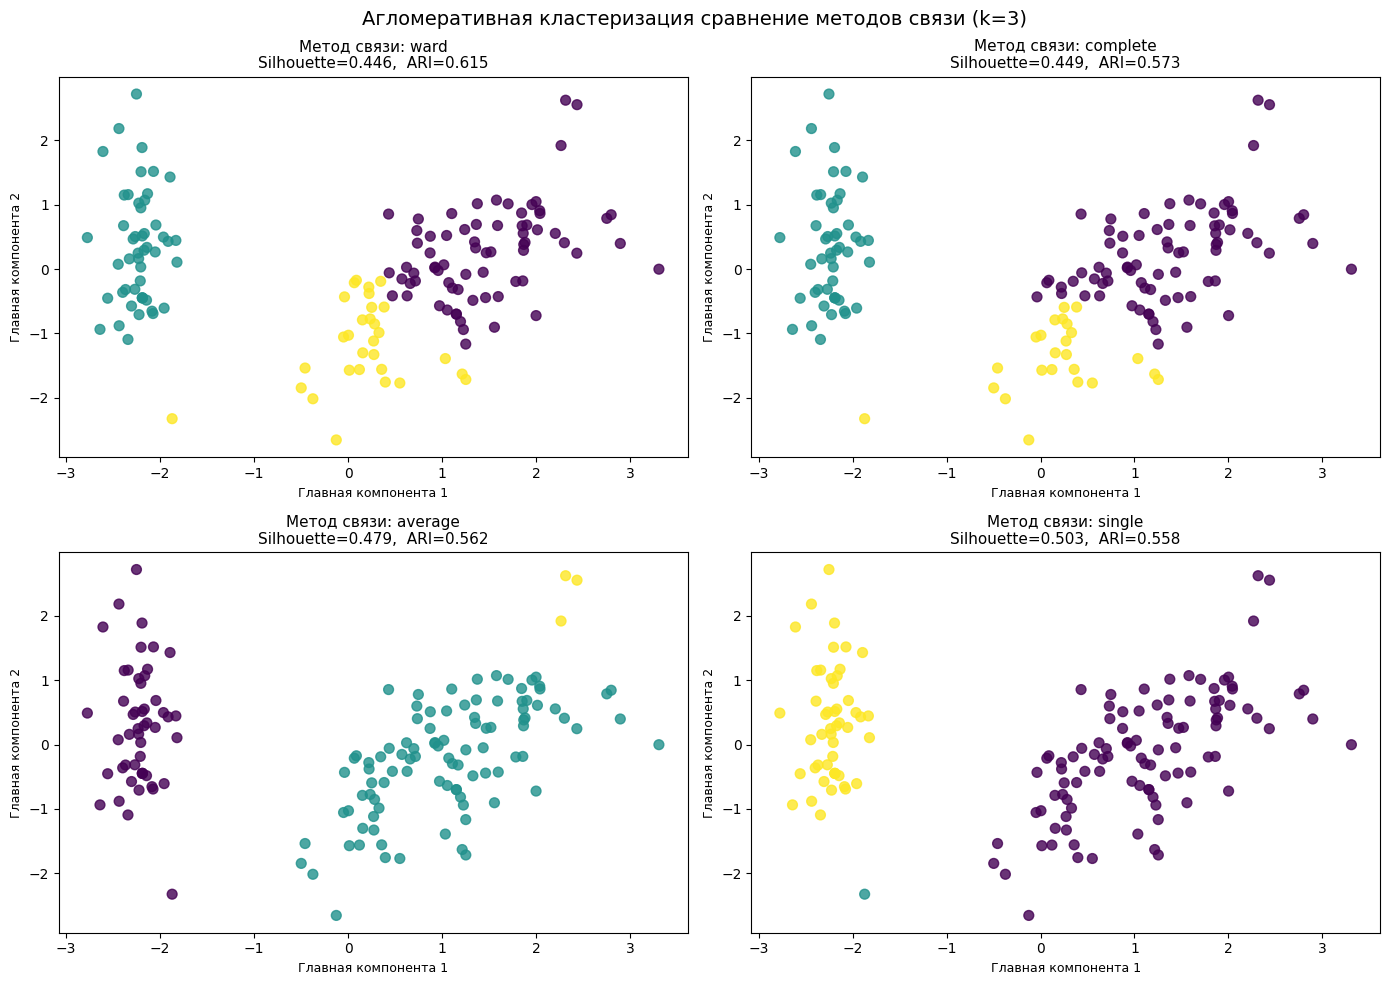

In [17]:
linkage_methods = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, method in zip(axes.flatten(), linkage_methods):
    agg = AgglomerativeClustering(n_clusters=3, linkage=method)
    y_pred_agg = agg.fit_predict(X_scaled_std)
    sil = metrics.silhouette_score(X_scaled_std, y_pred_agg)
    ari = metrics.adjusted_rand_score(y, y_pred_agg)
    ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_pred_agg, cmap='viridis', alpha=0.8, s=50)
    ax.set_title(f'Метод связи: {method}\nSilhouette={sil:.3f},  ARI={ari:.3f}', fontsize=11)
    ax.set_xlabel('Главная компонента 1', fontsize=9)
    ax.set_ylabel('Главная компонента 2', fontsize=9)

plt.suptitle('Агломеративная кластеризация сравнение методов связи (k=3)', fontsize=14)
plt.tight_layout()
plt.show()


Метод Ward даёт наиболее компактные кластеры

##### Кластеризация на основе плотности

In [18]:
eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [3, 5]

print(f'  eps  min_samples  Кластеров  Выбросов  Silhouette    ARI')
print('-' * 65)

best_eps, best_ms, best_sil = 0.5, 5, -1

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled_std)
        n_cl = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        if n_cl >= 2:
            sil = metrics.silhouette_score(X_scaled_std, labels)
            ari = metrics.adjusted_rand_score(y, labels)
            print(f'{eps:>5.1f}  {ms:>11}  {n_cl:>9}  {n_noise:>8}  {sil:>10.4f}  {ari:>6.4f}')
            if sil > best_sil:
                best_sil = sil
                best_eps, best_ms = eps, ms
        else:
            print(f'{eps:>5.1f}  {ms:>11}  {n_cl:>9}  {n_noise:>8}  {"N/A":>10}  {"N/A":>6}')

print(f'\nЛучшие параметры: eps={best_eps}, min_samples={best_ms}')


  eps  min_samples  Кластеров  Выбросов  Silhouette    ARI
-----------------------------------------------------------------
  0.3            3         10        84     -0.1418  0.1725
  0.3            5          3       120     -0.1927  0.0876
  0.5            3          7        18      0.1498  0.4413
  0.5            5          2        35      0.3492  0.4283
  0.7            3          2         6      0.5100  0.5464
  0.7            5          2         8      0.5192  0.5322
  1.0            3          2         1      0.5029  0.5584
  1.0            5          2         3      0.5371  0.5536

Лучшие параметры: eps=1.0, min_samples=5


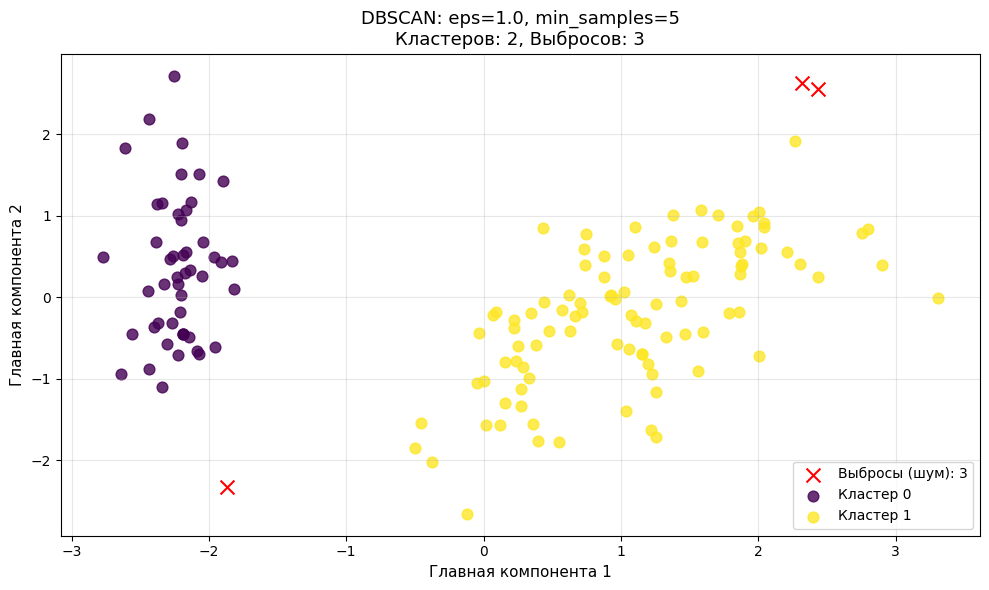

In [19]:
db_best = DBSCAN(eps=best_eps, min_samples=best_ms)
labels_best = db_best.fit_predict(X_scaled_std)

n_cl_found = len(set(labels_best)) - (1 if -1 in labels_best else 0)
n_noise = (labels_best == -1).sum()

plt.figure(figsize=(10, 6))
unique_labels = sorted(set(labels_best))
palette = plt.cm.viridis(np.linspace(0, 1, max(n_cl_found, 1)))
ci = 0
for lbl in unique_labels:
    mask = labels_best == lbl
    if lbl == -1:
        plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c='red', marker='x', s=100, label=f'Выбросы (шум): {n_noise}')
    else:
        plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=[palette[ci]], s=60, alpha=0.8, label=f'Кластер {lbl}')
        ci += 1

plt.title(f'DBSCAN: eps={best_eps}, min_samples={best_ms}\n'
          f'Кластеров: {n_cl_found}, Выбросов: {n_noise}', fontsize=13)
plt.xlabel('Главная компонента 1', fontsize=11)
plt.ylabel('Главная компонента 2', fontsize=11)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


##### Создание датасета с аномалиями

добавляем синтетические аномалии для демонстрации Isolation Forest.

In [20]:
n_outliers = 20
outliers = np.random.uniform(low=-4, high=4, size=(n_outliers, 4))
X_with_outliers = np.vstack([X_scaled_std, outliers])

print(f'Исходный датасет: {X_scaled_std.shape[0]} объектов')
print(f'Добавлено аномалий: {n_outliers}')
print(f'Итоговый датасет:  {X_with_outliers.shape[0]} объектов')


Исходный датасет: 150 объектов
Добавлено аномалий: 20
Итоговый датасет:  170 объектов


##### Isolation Forest

In [21]:
contamination = n_outliers / X_with_outliers.shape[0]

iso_forest = IsolationForest(contamination=contamination, random_state=0)
predictions = iso_forest.fit_predict(X_with_outliers)
# 1 = норма, -1 = аномалия

print(f'Обнаружено аномалий: {(predictions == -1).sum()}')
print(f'Нормальных объектов: {(predictions == 1).sum()}')
print(f'Точность обнаружения: {(predictions == -1).sum() / n_outliers * 100:.1f}%')


Обнаружено аномалий: 20
Нормальных объектов: 150
Точность обнаружения: 100.0%


синтетические аномалии были равномерно рассеяны далеко за пределами основных кластеров, поэтому такая точность

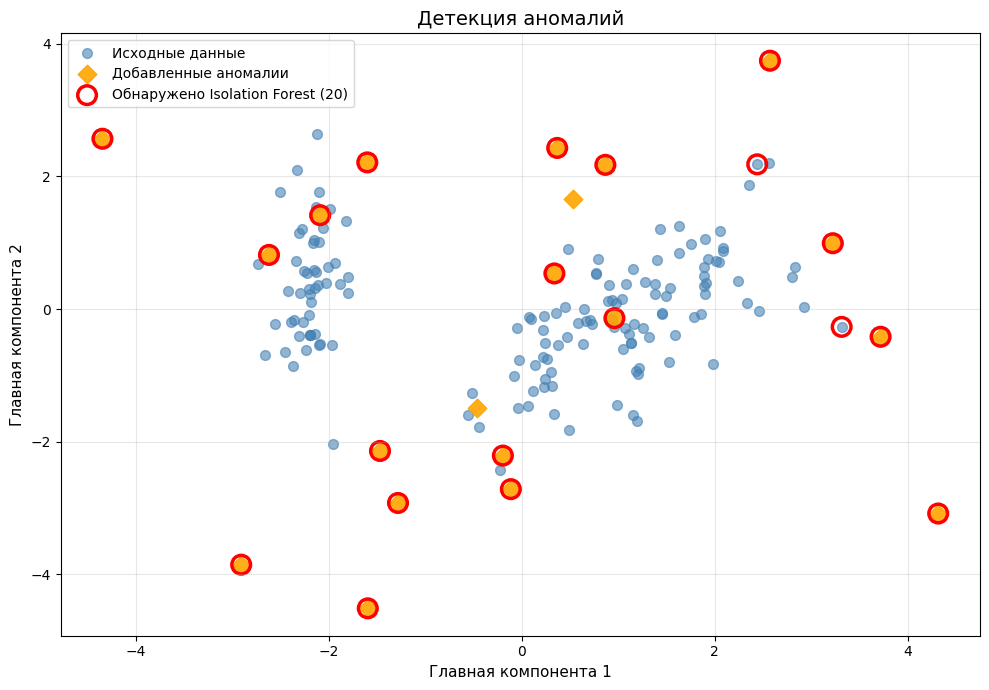

In [22]:
pca_out = PCA(n_components=2, random_state=0)
X_out_2d = pca_out.fit_transform(X_with_outliers)

orig_idx = np.arange(X_scaled_std.shape[0])
new_idx = np.arange(X_scaled_std.shape[0], X_with_outliers.shape[0])
mask_anomaly = predictions == -1

plt.figure(figsize=(10, 7))
plt.scatter(X_out_2d[orig_idx, 0], X_out_2d[orig_idx, 1],
            c='steelblue', alpha=0.6, s=50, label='Исходные данные')
plt.scatter(X_out_2d[new_idx, 0], X_out_2d[new_idx, 1],
            c='orange', marker='D', s=90, alpha=0.9, label='Добавленные аномалии')
plt.scatter(X_out_2d[mask_anomaly, 0], X_out_2d[mask_anomaly, 1],
            facecolors='none', edgecolors='red', linewidths=2.5, s=180,
            label=f'Обнаружено Isolation Forest ({mask_anomaly.sum()})')

plt.title('Детекция аномалий', fontsize=14)
plt.xlabel('Главная компонента 1', fontsize=11)
plt.ylabel('Главная компонента 2', fontsize=11)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


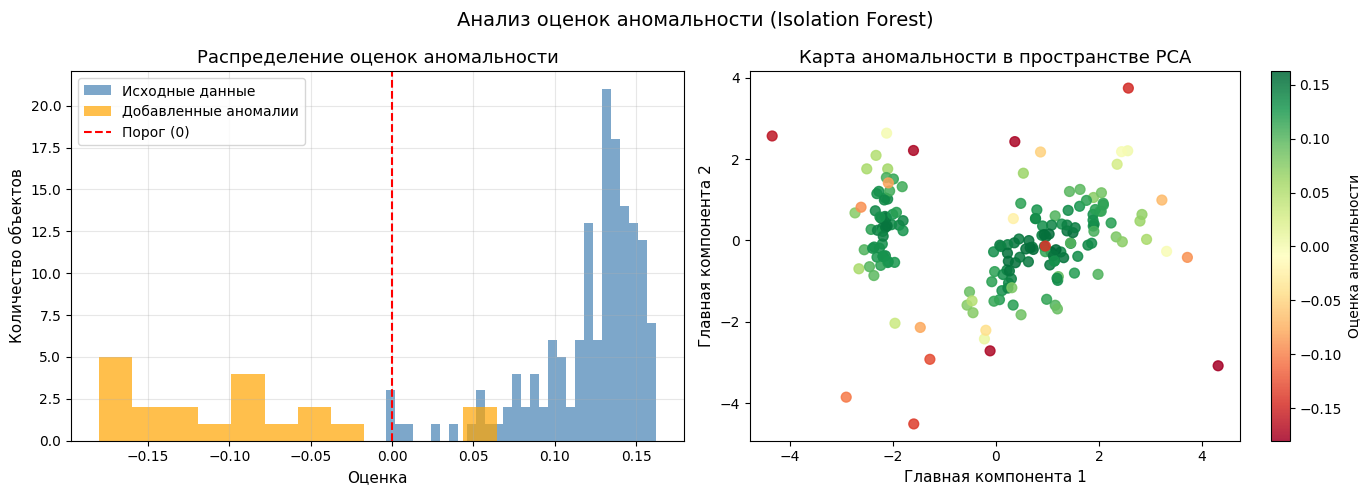

In [23]:
scores = iso_forest.decision_function(X_with_outliers)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(scores[orig_idx], bins=30, alpha=0.7, color='steelblue', label='Исходные данные')
axes[0].hist(scores[new_idx], bins=12, alpha=0.7, color='orange', label='Добавленные аномалии')
axes[0].axvline(x=0, color='red', linestyle='--', label='Порог (0)')
axes[0].set_title('Распределение оценок аномальности', fontsize=13)
axes[0].set_xlabel('Оценка', fontsize=11)
axes[0].set_ylabel('Количество объектов', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

sc = axes[1].scatter(X_out_2d[:, 0], X_out_2d[:, 1], c=scores, cmap='RdYlGn', s=50, alpha=0.85)
plt.colorbar(sc, ax=axes[1], label='Оценка аномальности')
axes[1].set_title('Карта аномальности в пространстве PCA', fontsize=13)
axes[1].set_xlabel('Главная компонента 1', fontsize=11)
axes[1].set_ylabel('Главная компонента 2', fontsize=11)

plt.suptitle('Анализ оценок аномальности (Isolation Forest)', fontsize=14)
plt.tight_layout()
plt.show()


#### Сводная таблица метрик

In [25]:
agg_ward = AgglomerativeClustering(n_clusters=3, linkage='ward')
y_agg = agg_ward.fit_predict(X_scaled_std)

db_final = DBSCAN(eps=best_eps, min_samples=best_ms)
labels_final = db_final.fit_predict(X_scaled_std)
n_cl_db = len(set(labels_final)) - (1 if -1 in labels_final else 0)

def safe_sil(Xd, labels):
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    return round(metrics.silhouette_score(Xd, labels), 4) if n_cl >= 2 else float('nan')

def safe_ari(y_true, labels):
    return round(metrics.adjusted_rand_score(y_true, labels), 4)

summary = pd.DataFrame({
    'Алгоритм': [
        'K-Means (k=3, без масштабирования)',
        'K-Means (k=3, StandardScaler)',
        'Иерархическая кластеризация (Ward)',
        f'DBSCAN (eps={best_eps}, min_samples={best_ms})'
    ],
    'Кластеров': [3, 3, 3, n_cl_db],
    'Silhouette': [
        safe_sil(X, y_pred_kmeans),
        safe_sil(X_scaled_std, y_pred_scaled),
        safe_sil(X_scaled_std, y_agg),
        safe_sil(X_scaled_std, labels_final)
    ],
    'ARI': [
        safe_ari(y, y_pred_kmeans),
        safe_ari(y, y_pred_scaled),
        safe_ari(y, y_agg),
        safe_ari(y, labels_final)
    ]
})

print('сравнение алгоритмов кластеризации')
print(summary.to_string(index=False))


сравнение алгоритмов кластеризации
                          Алгоритм  Кластеров  Silhouette    ARI
K-Means (k=3, без масштабирования)          3      0.5526 0.7302
     K-Means (k=3, StandardScaler)          3      0.4590 0.6201
Иерархическая кластеризация (Ward)          3      0.4455 0.6153
   DBSCAN (eps=1.0, min_samples=5)          2      0.5371 0.5536


Лучшим по обоим показателям оказался K-Means без масштабирования